In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
from MDSplus import Connection
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit
from pathlib import Path


def label_to_z(label):
    """
    convert labels like '\\B_n75' -> -75
    """
    m = re.search(r'\\B_([np])(\d+)', label)
    if m is None:
        raise ValueError(f"Could not parse label: {label}")
    sign = -1 if m.group(1) == 'n' else 1
    return sign * float(m.group(2))


def deflagration_window_piecewise(z):
    if z < -40:
        return (105, 115)
    else:
        return (110, 125)


def snowplow_window_piecewise(z):
    if z < -40:
        return (0, 15)
    else:
        return (10, 25)


def snowplow_model(t, z0, A, tau, t0):
    t = np.asarray(t, dtype=float)
    dt = np.maximum(t - t0, 0.0)
    return z0 + A * (np.exp(dt / tau) - 1.0)


def snowplow_speed(t, z0, A, tau, t0):
    t = np.asarray(t, dtype=float)
    dt = np.maximum(t - t0, 0.0)
    v = (A / tau) * np.exp(dt / tau)
    v[t < t0] = 0.0
    return v


def fit_snowplow(t_pick, z_pick):
    p0 = [
        np.min(z_pick),
        max(np.max(z_pick) - np.min(z_pick), 1e-3),
        10.0,
        np.min(t_pick)
    ]

    lower_bounds = [-np.inf, 0.0, 1e-6, np.min(t_pick) - 20]
    upper_bounds = [np.inf, np.inf, np.inf, np.max(t_pick)]

    popt, pcov = curve_fit(
        snowplow_model,
        t_pick,
        z_pick,
        p0=p0,
        bounds=(lower_bounds, upper_bounds),
        maxfev=20000
    )
    return popt, pcov


def fit_deflagration(t_pick, z_pick):
    m, b = np.polyfit(t_pick, z_pick, 1)
    return m, b


def fit_detonation(t_pick, z_pick):
    m, b = np.polyfit(t_pick, z_pick, 1)
    return m, b


def _safe_odd_window(requested_window, npts, polyorder):
    """
    Ensure Savitzky-Golay window is valid, odd, and not too large
    """
    if npts <= polyorder + 2:
        return None

    w = min(int(requested_window), int(npts))
    if w % 2 == 0:
        w -= 1

    min_allowed = polyorder + 2
    if min_allowed % 2 == 0:
        min_allowed += 1

    if w < min_allowed:
        w = min_allowed

    if w > npts:
        w = npts if npts % 2 == 1 else npts - 1

    if w <= polyorder or w < 3:
        return None

    return w


def filter_bdot_trace(
    t,
    B,
    smooth_window=101,
    polyorder=3,
    noise_window=(-20.0, -2.0),
    noise_gate_sigma=2.0,
    second_smooth_window=31,
):
    """
    Full magnetic field trace denoising

    Here are the steps:
    1. Savitzky-Golay smooth over full trace
    2. estimate baseline + noise from quiet pre-plasma interval
    3. subtract baseline
    4. soft threshold small fluctuations relative to baseline noise
    5. light second smoothing pass
    """
    t = np.asarray(t, dtype=float)
    B = np.asarray(B, dtype=float)

    w1 = _safe_odd_window(smooth_window, len(B), polyorder)
    if w1 is None:
        B_smooth = B.copy()
    else:
        B_smooth = savgol_filter(B, w1, polyorder)

    noise_mask = (t >= noise_window[0]) & (t <= noise_window[1])
    if np.count_nonzero(noise_mask) < 10:
        n_fallback = max(10, len(B_smooth) // 10)
        noise_mask = np.zeros_like(t, dtype=bool)
        noise_mask[:n_fallback] = True

    baseline = np.median(B_smooth[noise_mask])
    sigma = 1.4826 * np.median(np.abs(B_smooth[noise_mask] - baseline))

    B_centered = B_smooth - baseline

    if noise_gate_sigma is not None and sigma > 0:
        gate = float(noise_gate_sigma) * sigma
        B_denoised = np.sign(B_centered) * np.maximum(np.abs(B_centered) - gate, 0.0)
    else:
        gate = None
        B_denoised = B_centered

    w2 = _safe_odd_window(second_smooth_window, len(B_denoised), polyorder)
    if w2 is not None:
        B_denoised = savgol_filter(B_denoised, w2, polyorder)

    meta = {
        "baseline": baseline,
        "noise_sigma": sigma,
        "gate_level": gate,
        "smooth_window_1": w1,
        "smooth_window_2": w2,
    }
    return B_denoised, meta


def build_filtered_bdot_dict(
    bdot_data,
    labels,
    smooth_window=101,
    polyorder=3,
    noise_window=(-20.0, -2.0),
    noise_gate_sigma=2.0,
    second_smooth_window=31,
):
    filtered = {}
    filter_meta = {}

    for label in labels:
        t, B = bdot_data[label]
        B_filt, meta = filter_bdot_trace(
            t,
            B,
            smooth_window=smooth_window,
            polyorder=polyorder,
            noise_window=noise_window,
            noise_gate_sigma=noise_gate_sigma,
            second_smooth_window=second_smooth_window,
        )
        filtered[label] = (np.asarray(t, dtype=float), B_filt)
        filter_meta[label] = meta

    return filtered, filter_meta


def select_analysis_positions(valid_positions, z_max=0.0, exclude_z=None):
    """
    Choose which probes are used for filtering, picking, diagnostics, and fitting
    """
    if exclude_z is None:
        exclude_z = []

    exclude_z_set = {float(z) for z in exclude_z}

    analysis_positions = [
        p for p in valid_positions
        if (label_to_z(p) <= z_max) and (label_to_z(p) not in exclude_z_set)
    ]

    return analysis_positions


def _crossing_times(t, y, threshold, edge="rising"):
    """
    Return threshold crossing times using linear interpolation
    """
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    d = y - threshold
    tcross = []

    for i in range(len(d) - 1):
        d0 = d[i]
        d1 = d[i + 1]

        if edge == "rising":
            crossed = (d0 < 0 and d1 >= 0)
        elif edge == "falling":
            crossed = (d0 >= 0 and d1 < 0)
        elif edge == "any":
            crossed = ((d0 == 0) or (d1 == 0) or (np.sign(d0) != np.sign(d1)))
        else:
            raise ValueError("edge must be 'rising', 'falling', or 'any'")

        if crossed:
            if d1 == d0:
                tc = t[i]
            else:
                tc = t[i] - d0 * (t[i + 1] - t[i]) / (d1 - d0)
            tcross.append(tc)

    return np.array(tcross, dtype=float)


def pick_feature_times_from_filtered(
    filtered_bdot_data,
    labels,
    window_fn,
    feature='dBdt_max',
    min_prominence=None,
):
    """
    Gradient or extrema picking on already filtered traces
    """
    picked_t = []
    picked_z = []
    picked_amp = []

    for label in labels:
        t, Bf = filtered_bdot_data[label]
        t = np.asarray(t, dtype=float)
        Bf = np.asarray(Bf, dtype=float)
        z = label_to_z(label)

        t1, t2 = window_fn(z)
        mask = (t >= t1) & (t <= t2)

        if np.count_nonzero(mask) < 3:
            continue

        t_win = t[mask]
        B_win = Bf[mask]

        if feature == 'dBdt_max':
            y = np.gradient(B_win, t_win)
            idx = np.argmax(y)
            amp = y[idx]
        elif feature == 'dBdt_min':
            y = np.gradient(B_win, t_win)
            idx = np.argmin(y)
            amp = y[idx]
        elif feature == 'B_max':
            y = B_win
            idx = np.argmax(y)
            amp = y[idx]
        elif feature == 'B_min':
            y = B_win
            idx = np.argmin(y)
            amp = y[idx]
        else:
            raise ValueError("Invalid feature")

        if min_prominence is not None and np.abs(amp) < min_prominence:
            continue

        picked_t.append(t_win[idx])
        picked_z.append(z)
        picked_amp.append(amp)

    picked_t = np.asarray(picked_t, dtype=float)
    picked_z = np.asarray(picked_z, dtype=float)
    picked_amp = np.asarray(picked_amp, dtype=float)

    if picked_t.size > 0:
        order = np.argsort(picked_z)
        picked_t = picked_t[order]
        picked_z = picked_z[order]
        picked_amp = picked_amp[order]

    return picked_t, picked_z, picked_amp


def pick_threshold_times_from_filtered(
    filtered_bdot_data,
    labels,
    window_fn,
    threshold,
    edge='rising',
    fallback_to_any=False,
):
    """
    Threshold picking on the already filtered traces
    """
    picked_t = []
    picked_z = []
    picked_amp = []
    crossings_by_probe = {}

    for label in labels:
        t, Bf = filtered_bdot_data[label]
        z = label_to_z(label)

        t1, t2 = window_fn(z)
        mask = (t >= t1) & (t <= t2)

        if np.count_nonzero(mask) < 2:
            continue

        t_win = np.asarray(t[mask], dtype=float)
        B_win = np.asarray(Bf[mask], dtype=float)

        tcross = _crossing_times(t_win, B_win, threshold, edge=edge)

        used_fallback = False
        if tcross.size == 0 and fallback_to_any:
            tcross = _crossing_times(t_win, B_win, threshold, edge='any')
            used_fallback = tcross.size > 0

        if tcross.size > 0:
            t_pick = tcross[0] if edge == 'rising' else tcross[-1]
            picked_t.append(t_pick)
            picked_z.append(z)
            picked_amp.append(threshold)

        crossings_by_probe[label] = {
            "z": z,
            "crossings": tcross,
            "used_fallback_any": used_fallback,
        }

    picked_t = np.asarray(picked_t, dtype=float)
    picked_z = np.asarray(picked_z, dtype=float)
    picked_amp = np.asarray(picked_amp, dtype=float)

    if picked_t.size > 0:
        order = np.argsort(picked_z)
        picked_t = picked_t[order]
        picked_z = picked_z[order]
        picked_amp = picked_amp[order]

    return picked_t, picked_z, picked_amp, crossings_by_probe


def build_pick_lookup(labels, picked_t, picked_z, picked_amp=None):
    """
    Build per label lookup for picked times so example traces can show markers
    Assumes one probe per z location in analysis_positions
    """
    lookup = {}

    picked_t = np.asarray(picked_t, dtype=float)
    picked_z = np.asarray(picked_z, dtype=float)

    if picked_amp is None:
        picked_amp = np.full_like(picked_t, np.nan, dtype=float)
    else:
        picked_amp = np.asarray(picked_amp, dtype=float)

    for label in labels:
        z = label_to_z(label)
        idx = np.where(np.isclose(picked_z, z))[0]
        if idx.size > 0:
            i = idx[0]
            lookup[label] = {
                "t": float(picked_t[i]),
                "z": float(picked_z[i]),
                "amp": float(picked_amp[i]),
            }

    return lookup


def plot_filtered_traces(
    raw_bdot_data,
    filtered_bdot_data,
    labels,
    threshold=None,
    time_xlim=(-25, 150),
):
    """
    Diagnostic plot:
    top = raw traces
    bottom = filtered traces used for picking
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    for label in labels:
        t_raw, B_raw = raw_bdot_data[label]
        t_filt, B_filt = filtered_bdot_data[label]
        z = label_to_z(label)

        axes[0].plot(t_raw, B_raw, lw=1, alpha=0.65, label=f"{z:.0f} cm")
        axes[1].plot(t_filt, B_filt, lw=1.5, alpha=0.9, label=f"{z:.0f} cm")

    if threshold is not None:
        axes[1].axhline(threshold, ls='--', lw=1.5, color='k')

    axes[0].set_title("All raw B-dot traces, z <= 0")
    axes[1].set_title("All filtered B-dot traces, z <= 0")

    axes[0].set_ylabel("B [T]")
    axes[1].set_ylabel("Filtered B [T]")
    axes[1].set_xlabel("Time [μs]")

    axes[0].set_xlim(*time_xlim)
    axes[1].set_xlim(*time_xlim)

    handles, labels_leg = axes[1].get_legend_handles_labels()
    if len(handles) <= 12:
        axes[1].legend(ncol=2, fontsize=8)

    fig.tight_layout()
    return fig


def plot_filter_examples(
    raw_bdot_data,
    filtered_bdot_data,
    labels,
    threshold_lines=None,
    snow_pick_lookup=None,
    def_pick_lookup=None,
    max_examples=16,
    time_xlim=(-25, 150),
):
    """
    Representative raw vs filtered traces for analysis probes
    """
    if len(labels) == 0:
        return None

    if threshold_lines is None:
        threshold_lines = []

    idx = np.linspace(0, len(labels) - 1, min(max_examples, len(labels)), dtype=int)
    example_labels = [labels[i] for i in idx]

    fig, axes = plt.subplots(
        len(example_labels),
        1,
        figsize=(11, 2.2 * len(example_labels)),
        sharex=True
    )
    if len(example_labels) == 1:
        axes = [axes]

    for ax, label in zip(axes, example_labels):
        t_raw, B_raw = raw_bdot_data[label]
        t_filt, B_filt = filtered_bdot_data[label]
        z = label_to_z(label)

        ax.plot(t_raw, B_raw, alpha=0.45, lw=1.0, label='raw')
        ax.plot(t_filt, B_filt, lw=1.8, label='filtered')

        # Threshold lines
        for ythr, lab, color, ls in threshold_lines:
            ax.axhline(ythr, ls=ls, lw=1.2, color=color, label=lab)

        # Snowplow pick marker
        if snow_pick_lookup is not None and label in snow_pick_lookup:
            t_pick = snow_pick_lookup[label]["t"]
            y_pick = np.interp(t_pick, t_filt, B_filt)
            ax.plot(t_pick, y_pick, 'o', color='red', ms=5, label='snow pick')
            ax.axvline(t_pick, color='red', lw=0.8, alpha=0.35)

        # Deflagration pick marker
        if def_pick_lookup is not None and label in def_pick_lookup:
            t_pick = def_pick_lookup[label]["t"]
            y_pick = np.interp(t_pick, t_filt, B_filt)
            ax.plot(t_pick, y_pick, 'o', color='magenta', ms=5, label='def pick')
            ax.axvline(t_pick, color='magenta', lw=0.8, alpha=0.35)

        ax.set_ylabel(f"z={z:.0f}")
        ax.set_xlim(*time_xlim)

        # deduplicate legend entries
        handles, labs = ax.get_legend_handles_labels()
        unique = {}
        for h, l in zip(handles, labs):
            if l not in unique:
                unique[l] = h
        ax.legend(unique.values(), unique.keys(), loc='upper right', fontsize=8)

    axes[0].set_title("Representative raw vs filtered traces")
    axes[-1].set_xlabel("Time [μs]")
    fig.tight_layout()
    return fig


def magnetogram(shot, show_plot=True):
    accel_bdots = [rf'\B_n{i}' for i in range(75, 0, -5)]
    assem_bdots = [rf'\B_p{i}' for i in range(0, 50, 5)]
    bdots = accel_bdots + assem_bdots

    conn = Connection('172.25.35.206')
    conn.openTree('zaphd', shot)

    bdot_data = {key: (np.empty(0), np.empty(0)) for key in bdots}

    for bdot in bdots:
        try:
            data = conn.get(bdot)
            time = conn.get('dim_of(' + bdot + ')') * 10**6

            order = np.argsort(time)
            time = time[order]
            data = data[order]

            bdot_data[bdot] = (time, data)
        except Exception:
            print(f'No Tree Data for {bdot}')
            bdot_data[bdot] = (np.linspace(0, 200, 200), np.zeros(200))

    valid_positions = [
        pos for pos in bdot_data
        if bdot_data[pos][0].size > 1 and bdot_data[pos][1].size > 1
    ]

    z_positions = np.array([label_to_z(pos) for pos in valid_positions], dtype=float)

    all_times = np.concatenate([bdot_data[pos][0] for pos in valid_positions])
    min_time, max_time = np.min(all_times), np.max(all_times)
    num_points = 8192
    common_time = np.linspace(min_time, max_time, num_points)

    interpolated_signals = []
    for pos in valid_positions:
        time, signal = bdot_data[pos]
        interp_signal = np.interp(common_time, time, signal)
        interpolated_signals.append(interp_signal)

    heatmap_matrix = np.array(interpolated_signals)

    sort_idx = np.argsort(z_positions)
    z_positions = z_positions[sort_idx]
    valid_positions = [valid_positions[i] for i in sort_idx]
    heatmap_matrix = heatmap_matrix[sort_idx, :]

    dz = 5.0
    y_min = z_positions.min() - dz / 2
    y_max = z_positions.max() + dz / 2

    if show_plot:
        plt.figure(figsize=(10, 6))
        plt.imshow(
            heatmap_matrix,
            aspect='auto',
            extent=[common_time[0], common_time[-1], y_min, y_max],
            origin='lower',
            cmap='viridis',
            vmin=-0.05,
            vmax=0.3
        )
        plt.colorbar(label='Magnetic Field [T]')
        plt.xlabel('Time [μs]')
        plt.ylabel('Axial Position (cm)')
        plt.title(f'Shot: {shot}\nMagnetogram')
        plt.xlim([-20, 120])
        plt.yticks(np.arange(z_positions.min(), z_positions.max() + 5, 5))
        plt.show()

    return common_time, z_positions, heatmap_matrix, valid_positions, bdot_data


def analyze_speeds_for_shot(
    shot,
    snowplow_window_fn,
    deflagration_window_fn,

    snowplow_pick_method='threshold',
    deflagration_pick_method='gradient',

    snowplow_feature='dBdt_max',
    deflagration_feature='dBdt_min',

    threshold=None,
    snowplow_threshold=None,
    deflagration_threshold=None,

    detonation=True,
    smooth_window=101,
    polyorder=3,
    noise_window=(-20.0, 0),
    noise_gate_sigma=2.0,
    second_smooth_window=31,

    z_max=0.0,
    exclude_z=None,

    save_plots=False,
    save_dir='.',
    save_prefix=None,
    show_plots=True,
    example_max=16,
):
    """
    Analyze snowplow and defkagration speeds for one shot

    Both pick methods operate on the same filtered traces from filter_bdot_trace
    Analysis is restricted to probes with z <= 0
    """

    common_time, z_positions_full, M_full, valid_positions_full, bdot_data_full = magnetogram(
        shot,
        show_plot=False
    )

    analysis_positions = select_analysis_positions(
        valid_positions_full,
        z_max=z_max,
        exclude_z=exclude_z,
    )

    if len(analysis_positions) == 0:
        raise RuntimeError("No analysis probes remain after applying z_max and exclude_z.")

    bdot_data = {p: bdot_data_full[p] for p in analysis_positions}

    z_positions_plot = z_positions_full
    M_plot = M_full

    z_positions = np.array([label_to_z(p) for p in analysis_positions], dtype=float)

    filtered_bdot_data, filter_meta = build_filtered_bdot_dict(
        bdot_data,
        analysis_positions,
        smooth_window=smooth_window,
        polyorder=polyorder,
        noise_window=noise_window,
        noise_gate_sigma=noise_gate_sigma,
        second_smooth_window=second_smooth_window,
    )

    fig_filtered_all = plot_filtered_traces(
        bdot_data,
        filtered_bdot_data,
        analysis_positions,
        threshold=threshold,
        time_xlim=(-25, 150),
    )

    fig_filter_examples = None

    if snowplow_threshold is None:
        snowplow_threshold = threshold
    if deflagration_threshold is None:
        deflagration_threshold = threshold

    snowplow_crossings = None
    deflagration_crossings = None

    if snowplow_pick_method == 'gradient':
        t_snow, z_snow, a_snow = pick_feature_times_from_filtered(
            filtered_bdot_data,
            analysis_positions,
            window_fn=snowplow_window_fn,
            feature=snowplow_feature,
        )
    elif snowplow_pick_method == 'threshold':
        if snowplow_threshold is None:
            raise ValueError("snowplow_threshold or threshold must be provided for threshold snowplow picking.")
        t_snow, z_snow, a_snow, snowplow_crossings = pick_threshold_times_from_filtered(
            filtered_bdot_data,
            analysis_positions,
            window_fn=snowplow_window_fn,
            threshold=snowplow_threshold,
            edge='rising',
            fallback_to_any=False,
        )
    else:
        raise ValueError("snowplow_pick_method must be 'gradient' or 'threshold'")

    if deflagration_pick_method == 'gradient':
        t_def, z_def, a_def = pick_feature_times_from_filtered(
            filtered_bdot_data,
            analysis_positions,
            window_fn=deflagration_window_fn,
            feature=deflagration_feature,
        )
    elif deflagration_pick_method == 'threshold':
        if deflagration_threshold is None:
            raise ValueError("deflagration_threshold or threshold must be provided for threshold deflagration picking.")
        t_def, z_def, a_def, deflagration_crossings = pick_threshold_times_from_filtered(
            filtered_bdot_data,
            analysis_positions,
            window_fn=deflagration_window_fn,
            threshold=deflagration_threshold,
            edge='falling',
            fallback_to_any=True,
        )
    else:
        raise ValueError("deflagration_pick_method must be 'gradient' or 'threshold'")

    # Build per-trace pick lookups for diagnostics plotting
    snow_pick_lookup_all = build_pick_lookup(
        analysis_positions,
        t_snow,
        z_snow,
        a_snow,
    )
    def_pick_lookup_all = build_pick_lookup(
        analysis_positions,
        t_def,
        z_def,
        a_def,
    )

    # Only show per-trace markers for fronts that were picked by gradient
    snow_pick_lookup_plot = snow_pick_lookup_all if snowplow_pick_method == 'gradient' else None
    def_pick_lookup_plot = def_pick_lookup_all if deflagration_pick_method == 'gradient' else None

    # Threshold lines to show on example traces
    threshold_lines = []

    if snowplow_pick_method == 'threshold' and snowplow_threshold is not None:
        threshold_lines.append((snowplow_threshold, 'snow threshold', 'red', '--'))

    if deflagration_pick_method == 'threshold' and deflagration_threshold is not None:
        already_present = any(np.isclose(ythr, deflagration_threshold) for ythr, _, _, _ in threshold_lines)
        if not already_present:
            threshold_lines.append((deflagration_threshold, 'def threshold', 'magenta', '--'))

    fig_filter_examples = plot_filter_examples(
        bdot_data,
        filtered_bdot_data,
        analysis_positions,
        threshold_lines=threshold_lines,
        snow_pick_lookup=snow_pick_lookup_plot,
        def_pick_lookup=def_pick_lookup_plot,
        max_examples=example_max,
        time_xlim=(-25, 150),
    )

    if t_snow.size < 2 or t_def.size < 2:
        raise RuntimeError("Not enough picks for fitting. Adjust threshold, windows, or filtering.")

    t_dense_snow = np.linspace(t_snow.min(), t_snow.max(), 500)
    if detonation:
        m_snow, b_snow = fit_detonation(t_snow, z_snow)
        z_fit_snow = m_snow * t_dense_snow + b_snow
        v_fit_snow = np.full_like(t_dense_snow, m_snow)
        snow_params = None
        snow_cov = None
    else:
        snow_params, snow_cov = fit_snowplow(t_snow, z_snow)
        z_fit_snow = snowplow_model(t_dense_snow, *snow_params)
        v_fit_snow = snowplow_speed(t_dense_snow, *snow_params)
        m_snow = None
        b_snow = None

    m_def, b_def = fit_deflagration(t_def, z_def)
    t_dense_def = np.linspace(t_def.min(), t_def.max(), 500)
    z_fit_def = m_def * t_dense_def + b_def
    v_fit_def = np.full_like(t_dense_def, m_def)

    dz_plot = np.median(np.diff(np.sort(z_positions_plot))) if len(z_positions_plot) > 1 else 5.0
    y_min = z_positions_plot.min() - dz_plot / 2
    y_max = z_positions_plot.max() + dz_plot / 2

    fig1, ax1 = plt.subplots(figsize=(10, 6))
    im = ax1.imshow(
        M_plot,
        aspect='auto',
        extent=[common_time[0], common_time[-1], y_min, y_max],
        origin='lower',
        cmap='viridis',
        vmin=-0.05,
        vmax=0.3
    )
    fig1.colorbar(im, ax=ax1, label='Magnetic Field [T]')
    ax1.scatter(t_snow, z_snow, c='r', s=25, label='Snowplow picks')
    ax1.plot(t_dense_snow, z_fit_snow, 'r-', lw=2, label='Snowplow fit')
    ax1.scatter(t_def, z_def, c='magenta', s=25, label='Deflagration picks')
    ax1.plot(t_dense_def, z_fit_def, 'm-', lw=2, label='Deflagration fit')
    ax1.set_xlabel('Time [μs]')
    ax1.set_ylabel('Axial Position (cm)')
    ax1.set_title(
        f"Shot: {shot}\nTracked speeds "
        f"(snow={snowplow_pick_method}, def={deflagration_pick_method}, "
        f"analysis: z<={z_max}, exclude_z={exclude_z})"
    )
    ax1.set_xlim(-20, 150)
    ax1.set_yticks(
        np.arange(
            np.ceil(z_positions_plot.min() / 5) * 5,
            z_positions_plot.max() + 5,
            5
        )
    )
    ax1.legend()

    fig2, ax2 = plt.subplots(figsize=(8, 5))
    ax2.plot(t_dense_snow, v_fit_snow, label='Snowplow speed')
    ax2.plot(t_dense_def, v_fit_def, label='Deflagration speed')
    ax2.set_xlabel('Time [μs]')
    ax2.set_ylabel('dz/dt [cm / μs]')
    ax2.set_title(
        f"Shot: {shot}\nAccelerator Speeds "
        f"(snow={snowplow_pick_method}, def={deflagration_pick_method})"
    )
    ax2.legend()

    filtered_all_path = None
    filter_examples_path = None
    overlay_path = None
    speed_path = None

    if save_plots:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)

        if save_prefix is None:
            save_prefix = f"shot_{shot}"

        filtered_all_path = save_dir / f"{save_prefix}_filtered_traces_zle0.png"
        filter_examples_path = save_dir / f"{save_prefix}_filter_examples_zle0.png"
        overlay_path = save_dir / (
            f"{save_prefix}_tracked_speeds_snow_{snowplow_pick_method}_def_{deflagration_pick_method}.png"
        )
        speed_path = save_dir / (
            f"{save_prefix}_accelerator_speeds_snow_{snowplow_pick_method}_def_{deflagration_pick_method}.png"
        )

        fig_filtered_all.savefig(filtered_all_path, dpi=300, bbox_inches='tight')
        if fig_filter_examples is not None:
            fig_filter_examples.savefig(filter_examples_path, dpi=300, bbox_inches='tight')
        fig1.savefig(overlay_path, dpi=300, bbox_inches='tight')
        fig2.savefig(speed_path, dpi=300, bbox_inches='tight')

    if show_plots:
        plt.show()
    else:
        plt.close(fig_filtered_all)
        if fig_filter_examples is not None:
            plt.close(fig_filter_examples)
        plt.close(fig1)
        plt.close(fig2)

    results = {
        'shot': shot,

        'common_time': common_time,
        'z_positions': z_positions,
        'magnetogram': M_plot,
        'analysis_positions': analysis_positions,
        'z_max': z_max,
        'exclude_z': exclude_z,

        'bdot_data': bdot_data,
        'filtered_bdot_data': filtered_bdot_data,
        'filter_meta': filter_meta,

        'snowplow_pick_method': snowplow_pick_method,
        'deflagration_pick_method': deflagration_pick_method,
        'threshold': threshold,
        'snowplow_threshold': snowplow_threshold,
        'deflagration_threshold': deflagration_threshold,

        'snowplow_crossings': snowplow_crossings,
        'deflagration_crossings': deflagration_crossings,
        'snow_pick_lookup': snow_pick_lookup_all,
        'def_pick_lookup': def_pick_lookup_all,

        't_snow': t_snow,
        'z_snow': z_snow,
        'a_snow': a_snow,

        't_def': t_def,
        'z_def': z_def,
        'a_def': a_def,

        'm_snow': m_snow,
        'b_snow': b_snow,
        'snow_params': snow_params,
        'snow_cov': snow_cov,

        'm_def': m_def,
        'b_def': b_def,

        't_dense_snow': t_dense_snow,
        'z_fit_snow': z_fit_snow,
        'v_fit_snow': v_fit_snow,

        't_dense_def': t_dense_def,
        'z_fit_def': z_fit_def,
        'v_fit_def': v_fit_def,

        'fig_filtered_all': fig_filtered_all,
        'fig_filter_examples': fig_filter_examples,
        'fig_tracked_speeds': fig1,
        'fig_speeds': fig2,

        'filtered_traces_path': filtered_all_path,
        'filter_examples_path': filter_examples_path,
        'tracked_speeds_path': overlay_path,
        'speeds_path': speed_path,
    }

    return results

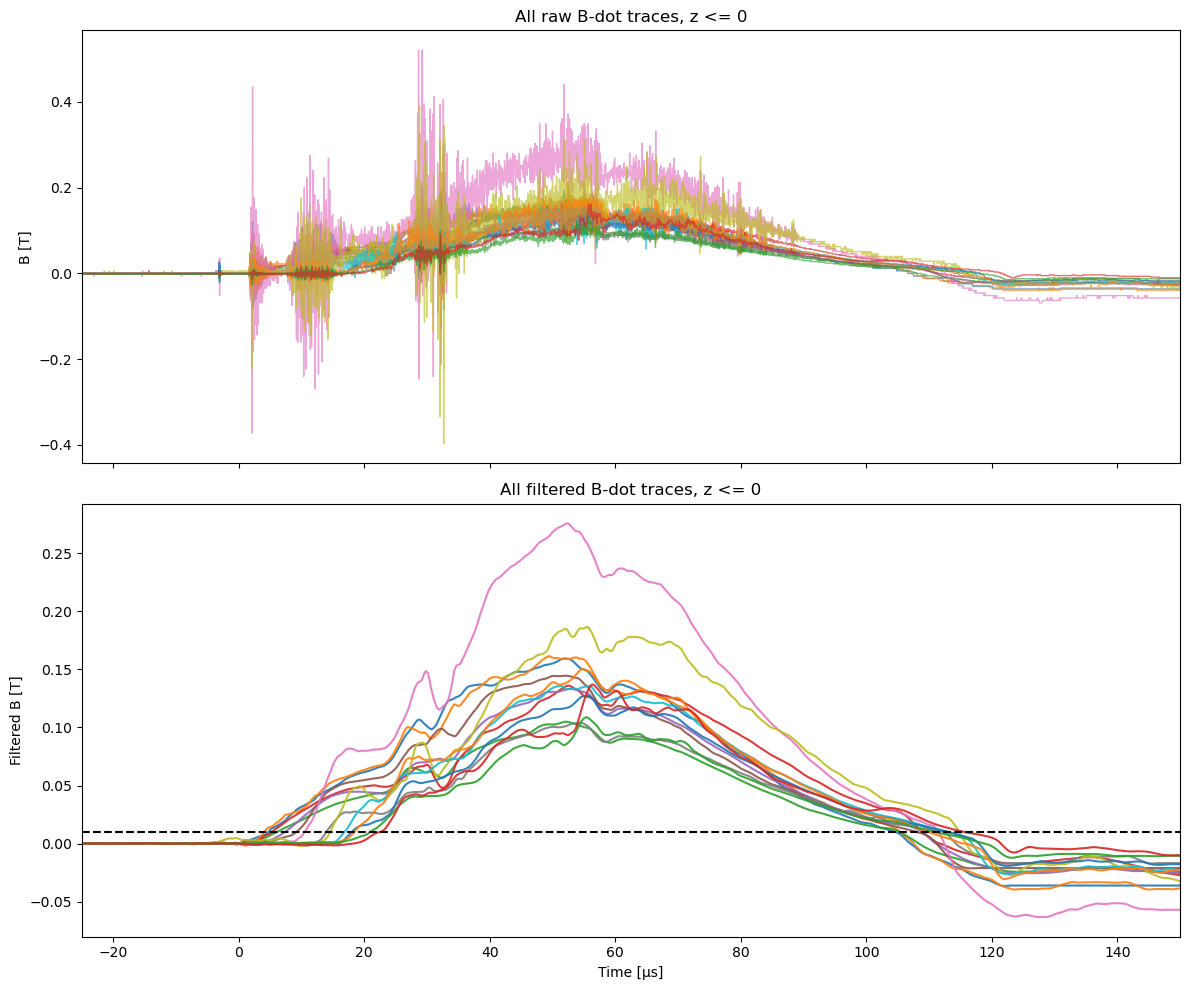

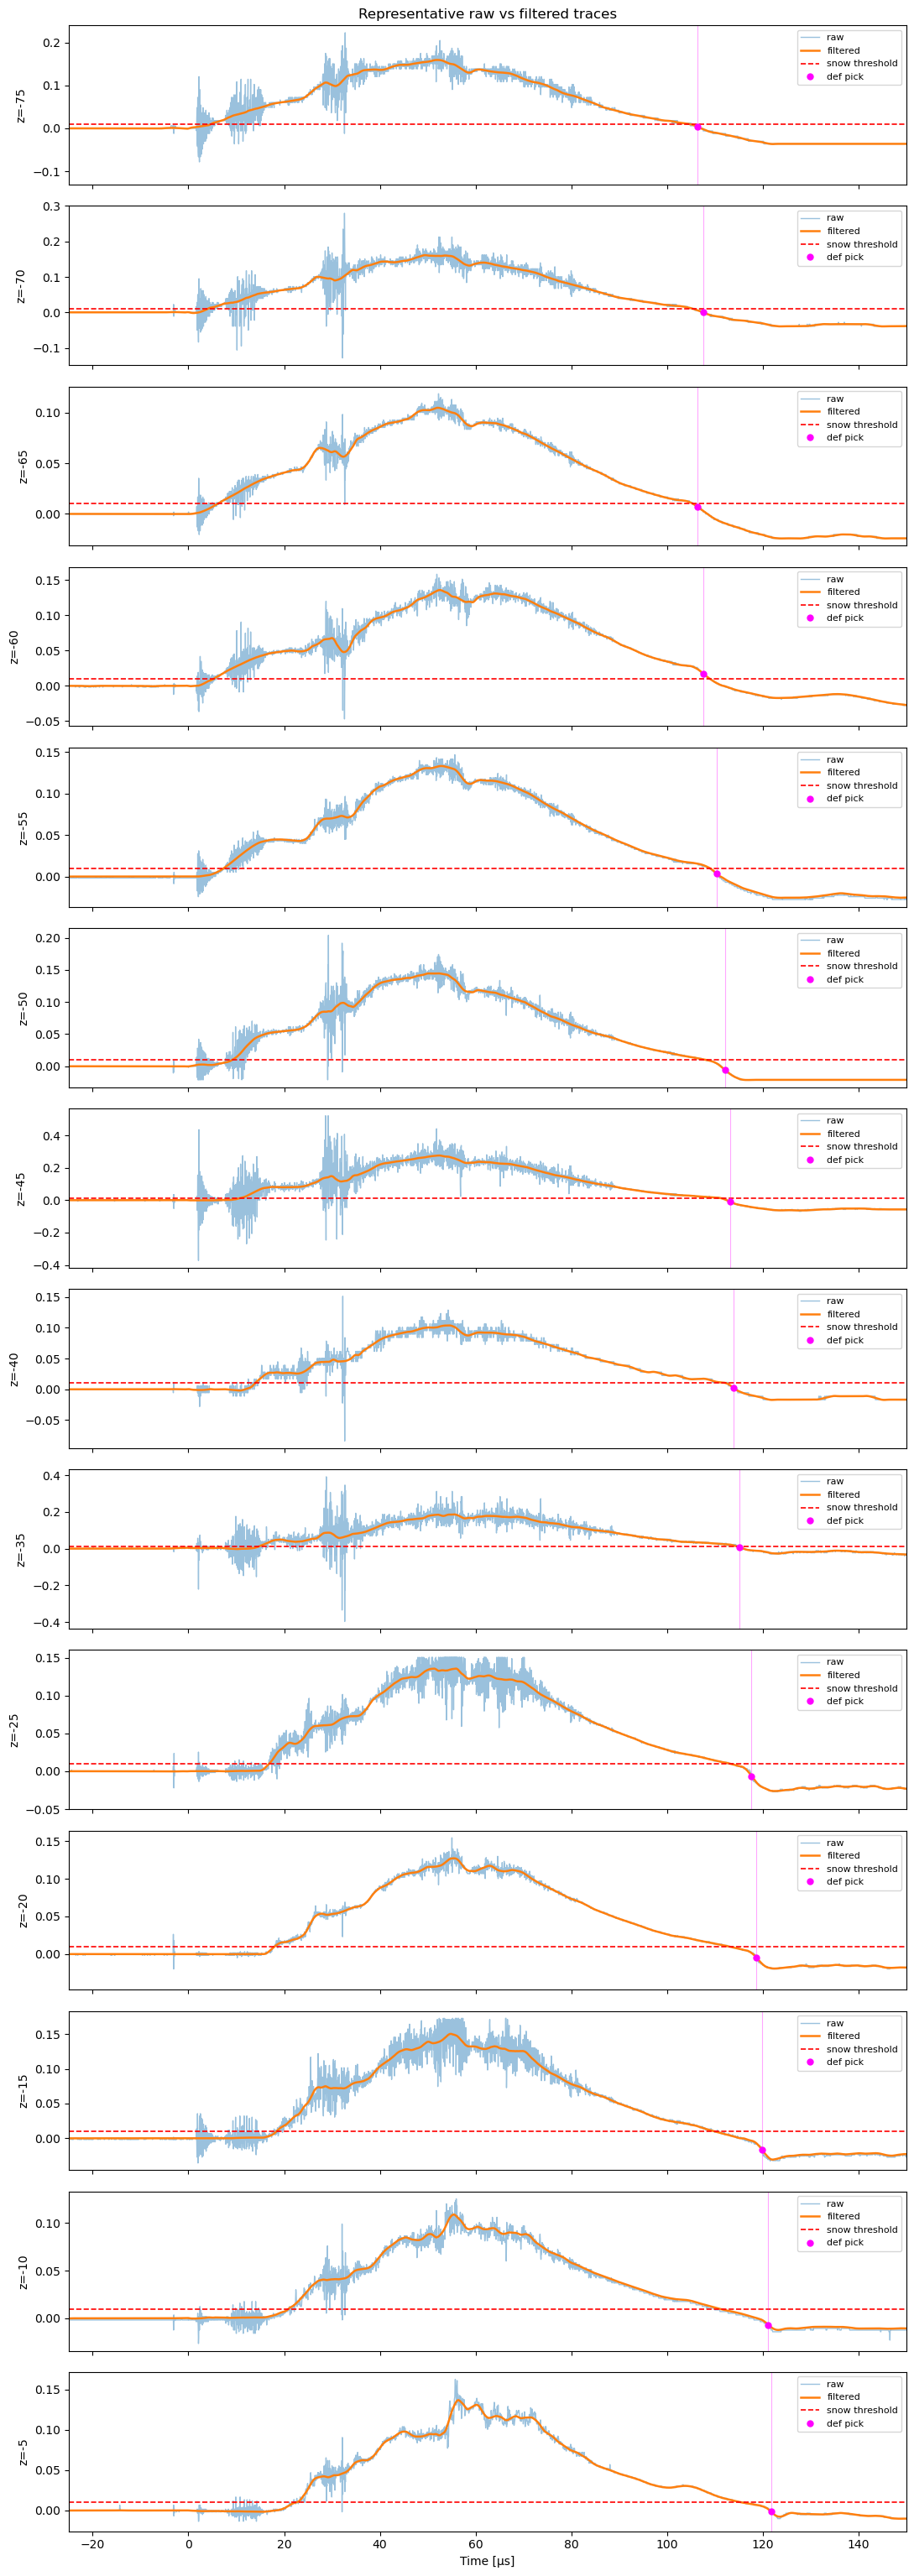

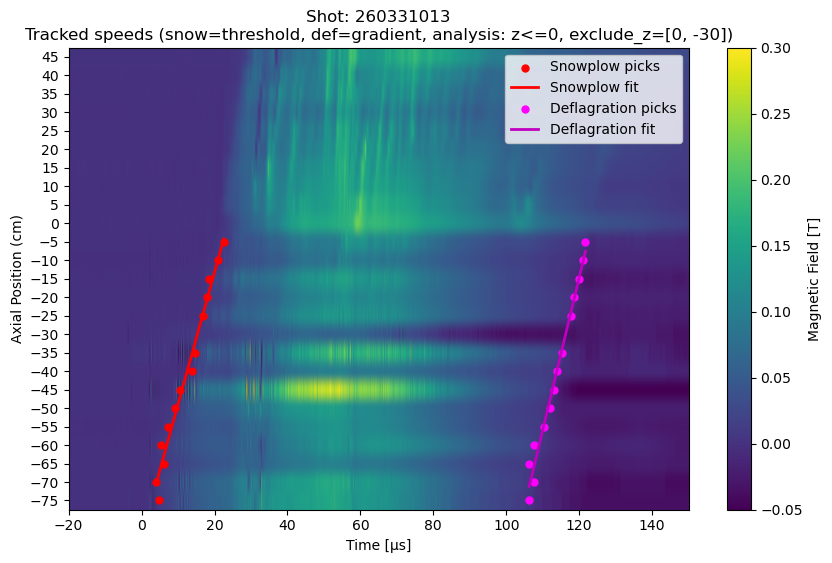

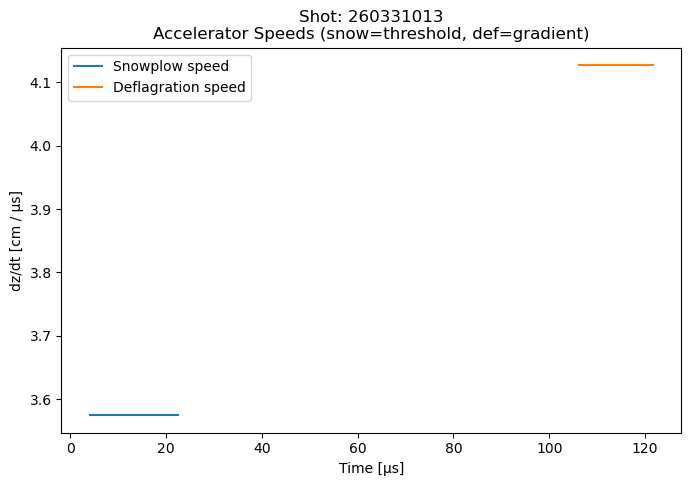

Detonation slope: 3.5744988293340705 cm / μs
Snowplow fit params [z0, A, tau, t0]: None
Deflagration slope: 4.127093567076334 cm / μs
Filtered traces plot saved to: None
Filter examples plot saved to: None
Tracked-fronts plot saved to: None
Speed plot saved to: None


In [2]:
shot = 260331013

results = analyze_speeds_for_shot(
    shot=shot,
    snowplow_window_fn=snowplow_window_piecewise,
    deflagration_window_fn=deflagration_window_piecewise,

    snowplow_pick_method='threshold',
    deflagration_pick_method='gradient',

    snowplow_feature='dBdt_max',
    deflagration_feature='dBdt_min',

    threshold=0.01,
    snowplow_threshold=0.01,
    deflagration_threshold=None,

    detonation=True,
    smooth_window=101,
    polyorder=3,
    noise_window=(-20, 0),
    noise_gate_sigma=2.0,
    second_smooth_window=31,

    z_max=0,
    exclude_z=[0, -30],

    example_max=16,

    save_plots=False,
    save_dir=r"C:\Users\ahada\OneDrive\University of Washington\Z-Pinch Fusion\scripts\bdot probes\speed_tracking_outputs",
    save_prefix=str(shot),
    show_plots=True,
)

print("Detonation slope:", results['m_snow'], "cm / μs")
print("Snowplow fit params [z0, A, tau, t0]:", results['snow_params'])
print("Deflagration slope:", results['m_def'], "cm / μs")
print("Filtered traces plot saved to:", results['filtered_traces_path'])
print("Filter examples plot saved to:", results['filter_examples_path'])
print("Tracked-fronts plot saved to:", results['tracked_speeds_path'])
print("Speed plot saved to:", results['speeds_path'])